# EDA: TB Recovery Check
## Exploratory Data Analysis of MTI-Plus Cohort

This notebook covers:
1. Dataset overview and shape
2. Missing value analysis
3. Demographic distributions (age, sex)
4. Clinical symptom patterns
5. HIV status and comorbidities
6. Follow-up data analysis
7. Healthy contacts analysis
8. Target variable exploration (Aim 1 & Aim 2)

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load_data import (
    load_merged_patients, load_demographic_patients,
    load_followup, load_healthy_contacts
)
from src.data.clean_data import (
    clean_patients, clean_followup, clean_healthy_contacts,
    build_aim1_dataset, build_aim2_dataset
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

---
## 1. Dataset Overview

In [2]:
df_merged = clean_patients(load_merged_patients())
df_pat = clean_patients(load_demographic_patients())
df_fu = clean_followup(load_followup())
df_hc = clean_healthy_contacts(load_healthy_contacts())
df_aim1 = build_aim1_dataset()
df_aim2 = build_aim2_dataset()

datasets = {
    'Merged Patients': df_merged,
    'Demographic Patients': df_pat,
    'Follow-up Visits': df_fu,
    'Healthy Contacts': df_hc,
    'Aim 1 (Non-conversion)': df_aim1,
    'Aim 2 (Contact Risk)': df_aim2,
}

overview = pd.DataFrame({
    'Rows': [len(v) for v in datasets.values()],
    'Columns': [len(v.columns) for v in datasets.values()],
    'Missing %': [round(v.isna().sum().sum() / (v.shape[0] * v.shape[1]) * 100, 1) for v in datasets.values()],
}, index=datasets.keys())
overview

/home/asj/Internship(Mak-ai)/TB_RECOVERY_CHECK/notebooks/../src/data/clean_data.py:173: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ].max(axis=1).fillna(0).astype(int)


,Rows,Columns,Missing %
Merged Patients,218,46,29.7
Demographic Patients,218,49,22.0
Follow-up Visits,81,34,42.2
Healthy Contacts,46,26,34.2
Aim 1 (Non-conversion),218,57,29.4
Aim 2 (Contact Risk),46,34,26.2


---
## 2. Missing Value Analysis

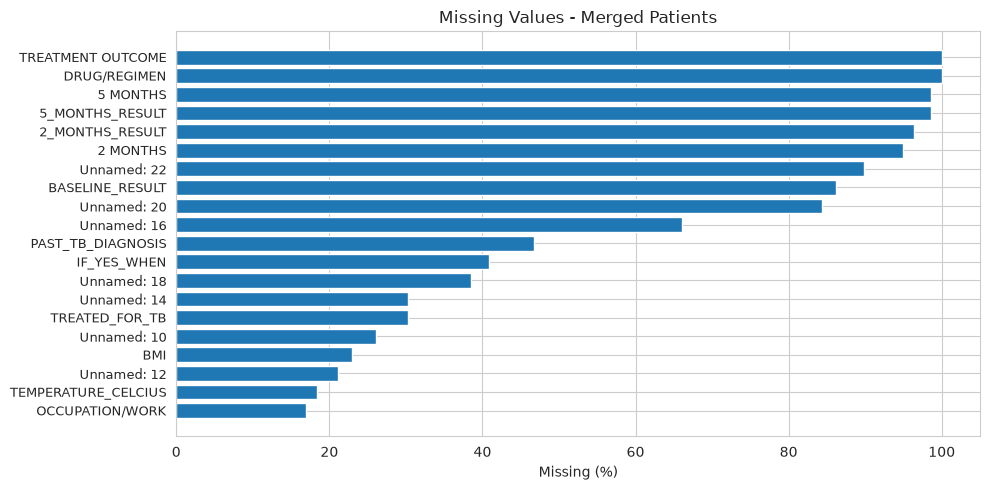

In [3]:
def plot_missing(df, title, top_n=20):
    missing = df.isna().mean().sort_values(ascending=False).head(top_n)
    missing = missing[missing > 0]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(range(len(missing)), missing.values * 100)
    ax.set_yticks(range(len(missing)))
    ax.set_yticklabels(missing.index, fontsize=9)
    ax.set_xlabel('Missing (%)')
    ax.set_title(f'Missing Values - {title}')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

plot_missing(df_merged, 'Merged Patients')

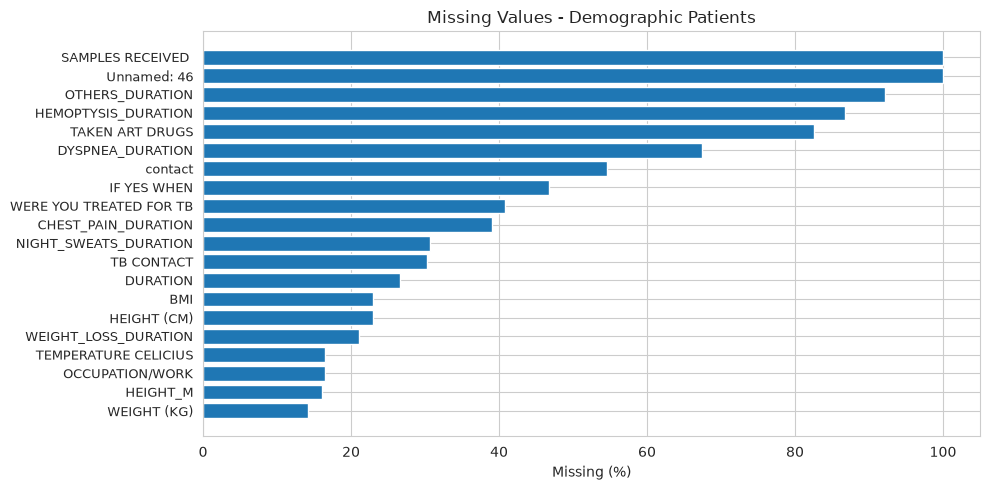

In [4]:
plot_missing(df_pat, 'Demographic Patients')

---
## 3. Demographics

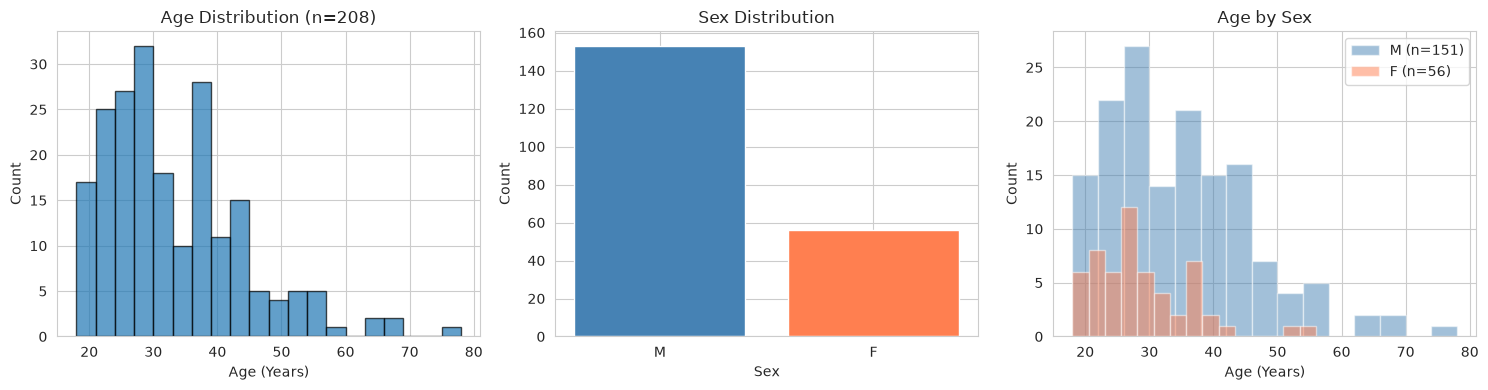

Sex distribution: {'M': 153, 'F': 56}


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age distribution
axes[0].hist(df_merged['AGE (YEARS)'].dropna(), bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Age Distribution (n={df_merged["AGE (YEARS)"].notna().sum()})')

# Sex distribution
sex_counts = df_merged['SEX'].value_counts()
axes[1].bar(sex_counts.index, sex_counts.values, color=['steelblue', 'coral'])
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Sex Distribution')

# Age by sex
for sex, color in [('M', 'steelblue'), ('F', 'coral')]:
    ages = df_merged[df_merged['SEX'] == sex]['AGE (YEARS)'].dropna()
    axes[2].hist(ages, bins=15, alpha=0.5, label=f'{sex} (n={len(ages)})', color=color)
axes[2].set_xlabel('Age (Years)')
axes[2].set_ylabel('Count')
axes[2].set_title('Age by Sex')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Sex distribution: {sex_counts.to_dict()}")

---
## 4. Clinical Symptoms at Baseline

In [6]:
symptom_cols = ['COUGH', 'FEVER', 'WEIGHT LOSS', 'NIGHT SWEATS', 'DYSPENA', 'CHEST PAIN', 'HEMOPTYSIS']
available = [c for c in symptom_cols if c in df_merged.columns]

if available:
    fig, ax = plt.subplots(figsize=(10, 5))
    symptom_data = []
    for col in available:
        counts = df_merged[col].value_counts()
        yes_pct = counts.get('YES', 0) / counts.sum() * 100 if counts.sum() > 0 else 0
        symptom_data.append({'Symptom': col, 'YES (%)': yes_pct, 'Count (YES)': counts.get('YES', 0)})

    df_symp = pd.DataFrame(symptom_data).sort_values('YES (%)', ascending=True)
    ax.barh(df_symp['Symptom'], df_symp['YES (%)'], color='tomato')
    for i, (_, row) in enumerate(df_symp.iterrows()):
        ax.text(row['YES (%)'] + 0.5, i, f"{int(row['Count (YES)'])}", va='center', fontsize=10)
    ax.set_xlabel('Patients with Symptom (%)')
    ax.set_title('Baseline Symptom Prevalence')
    plt.tight_layout()
    plt.show()
else:
    print('No symptom columns found in merged data.')
    print(f'Available columns: {list(df_merged.columns)}')

No symptom columns found in merged data.
Available columns: ['Sample ID', 'SEX', 'AGE (YEARS)', 'BASELINE', 'BASELINE_RESULT', 'COMPLICATIONS OF A TB PATIENT', 'TEMPERATURE_CELCIUS', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', '2 MONTHS', '2_MONTHS_RESULT', '5 MONTHS', '5_MONTHS_RESULT', 'DRUG/REGIMEN', 'TREATMENT OUTCOME', 'HIGHEST LEVEL OF EDUCATION (None/Primary/Secondary/Higher[S5/6]/Tertiary)', 'OCCUPATION/WORK', 'WEIGHT (KG)', 'HEIGHT (M)', 'BMI', 'COMOBIDITIES', 'HIV_STATUS', 'HAS_DIABETES', 'RISK FACTORS', 'SMOKES', 'CONSUMES_ALCOHOL', 'PAST_TB_DIAGNOSIS', 'IF_YES_WHEN', 'TREATED_FOR_TB', 'TB_CONTACT', 'NUMBER_OF_OCCUPANTS', 'SOURCE']


---
## 5. HIV Status & Comorbidities

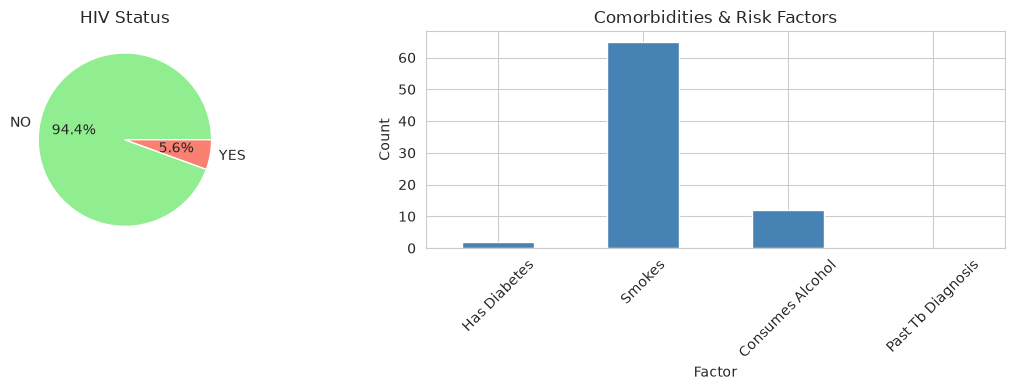

In [7]:
hiv_statuses = df_merged['HIV_STATUS'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(hiv_statuses.values, labels=hiv_statuses.index, autopct='%1.1f%%', 
            colors=['lightgreen', 'salmon', 'lightgray'])
axes[0].set_title('HIV Status')

comorbidity_cols = ['HAS_DIABETES', 'SMOKES', 'CONSUMES_ALCOHOL', 'PAST_TB_DIAGNOSIS']
avail_com = [c for c in comorbidity_cols if c in df_merged.columns]
com_data = []
for col in avail_com:
    yes_count = (df_merged[col] == 'YES').sum()
    com_data.append({'Factor': col.replace('_', ' ').title(), 'Count': yes_count})

pd.DataFrame(com_data).plot(kind='bar', x='Factor', y='Count', ax=axes[1], legend=False, color='steelblue')
axes[1].set_title('Comorbidities & Risk Factors')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 6. Follow-up Data

Follow-up visit distribution:
FOLLOW UP MONTH
MONTH_2    58
MONTH_5    19
Name: count, dtype: int64


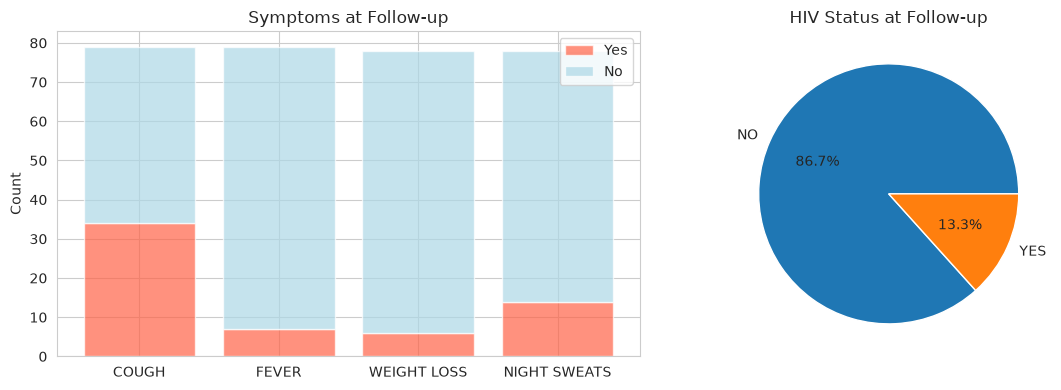

In [8]:
print("Follow-up visit distribution:")
print(df_fu['FOLLOW UP MONTH'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Symptoms at follow-up
fu_symptom_cols = ['COUGH', 'FEVER', 'WEIGHT LOSS', 'NIGHT SWEATS']
for col in fu_symptom_cols:
    if col in df_fu.columns:
        counts = df_fu[col].value_counts()
        axes[0].bar(col, counts.get('YES', 0), color='tomato', alpha=0.7)
        axes[0].bar(col, counts.get('NO', 0), bottom=counts.get('YES', 0), color='lightblue', alpha=0.7)
axes[0].set_title('Symptoms at Follow-up')
axes[0].set_ylabel('Count')
axes[0].legend(['Yes', 'No'])

# HIV at follow-up
if 'HIV STATUS' in df_fu.columns:
    fu_hiv = df_fu['HIV STATUS'].value_counts()
    axes[1].pie(fu_hiv.values, labels=fu_hiv.index, autopct='%1.1f%%')
    axes[1].set_title('HIV Status at Follow-up')

plt.tight_layout()
plt.show()

---
## 7. Healthy Contacts Analysis

In [9]:
print(f"Healthy contacts: {len(df_hc)}")
print(f"\nAge range: {df_hc['AGE'].min():.0f} - {df_hc['AGE'].max():.0f} years")
print(f"Sex distribution: {df_hc['SEX'].value_counts().to_dict()}")
print(f"\nSymptom prevalence:")
for col in ['COUGH', 'FEVER', 'WEIGHT LOSS', 'NIGHT SWEATS']:
    if col in df_hc.columns:
        counts = df_hc[col].value_counts()
        yes_pct = counts.get('YES', 0) / len(df_hc) * 100
        print(f"  {col}: {counts.get('YES', 0)} ({yes_pct:.1f}%)")

print(f"\nHIV Status: {df_hc['HIV STATUS'].value_counts().to_dict()}")

Healthy contacts: 46

Age range: 18 - 57 years
Sex distribution: {'M': 27, 'F': 19}

Symptom prevalence:
  COUGH: 10 (21.7%)
  FEVER: 1 (2.2%)
  WEIGHT LOSS: 4 (8.7%)
  NIGHT SWEATS: 2 (4.3%)

HIV Status: {'NO': 45}


---
## 8. Target Variable Exploration

=== AIM 1: Non-conversion at M2/M6 ===
Labeled samples: 218
Non-converters (1): 6
Converters (0): 212

=== AIM 2: Contact Risk (Symptom Proxy) ===
Total contacts: 46
Symptomatic (1): 10
Asymptomatic (0): 36


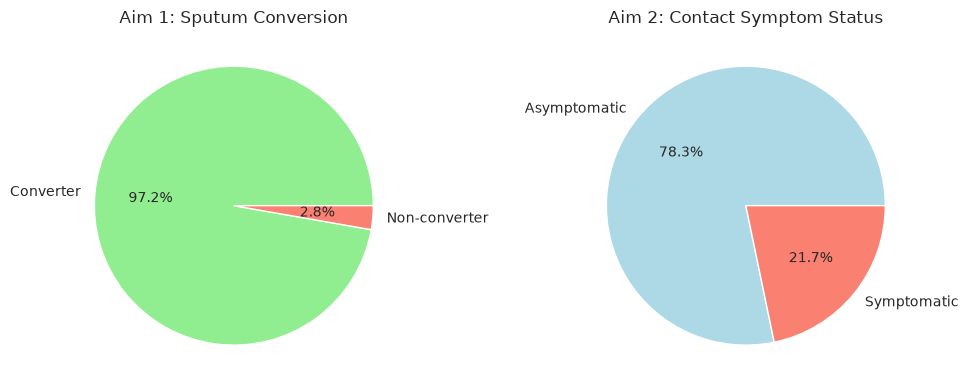

In [10]:
print("=== AIM 1: Non-conversion at M2/M6 ===")
print(f"Labeled samples: {df_aim1['TARGET_NON_CONVERSION_ANY'].notna().sum()}")
print(f"Non-converters (1): {df_aim1['TARGET_NON_CONVERSION_ANY'].sum():.0f}")
print(f"Converters (0): {(df_aim1['TARGET_NON_CONVERSION_ANY'] == 0).sum()}")

print(f"\n=== AIM 2: Contact Risk (Symptom Proxy) ===")
print(f"Total contacts: {len(df_aim2)}")
print(f"Symptomatic (1): {df_aim2['TARGET_SYMPTOM_PRESENT'].sum()}")
print(f"Asymptomatic (0): {(df_aim2['TARGET_SYMPTOM_PRESENT'] == 0).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

if df_aim1['TARGET_NON_CONVERSION_ANY'].notna().sum() > 0:
    target1 = df_aim1['TARGET_NON_CONVERSION_ANY'].dropna().astype(int)
    axes[0].pie(target1.value_counts().values, labels=['Converter', 'Non-converter'],
                autopct='%1.1f%%', colors=['lightgreen', 'salmon'])
    axes[0].set_title('Aim 1: Sputum Conversion')

target2 = df_aim2['TARGET_SYMPTOM_PRESENT']
axes[1].pie(target2.value_counts().values, labels=['Asymptomatic', 'Symptomatic'],
            autopct='%1.1f%%', colors=['lightblue', 'salmon'])
axes[1].set_title('Aim 2: Contact Symptom Status')

plt.tight_layout()
plt.show()

In [11]:
print("\n=== Key Findings Summary ===")
print(f"1. Total patients: {len(df_merged)}")
print(f"2. Mean age: {df_merged['AGE (YEARS)'].mean():.1f} years")
print(f"3. Male proportion: {(df_merged['SEX'] == 'M').mean() * 100:.1f}%")
print(f"4. HIV positive: {(df_merged['HIV_STATUS'] == 'YES').mean() * 100:.1f}%")
print(f"5. Baseline sputum positive: {(df_merged['BASELINE_RESULT'].isin(['MBTc Positive', 'MTBc Positive'])).sum()}")
print(f"6. 2-month conversion data available for: {df_aim1['TARGET_NON_CONVERSION_2M'].notna().sum()} patients")
print(f"7. 5-month conversion data available for: {df_aim1['TARGET_NON_CONVERSION_5M'].notna().sum()} patients")
print(f"8. Healthy contacts: {len(df_hc)}")
print(f"9. Contacts with symptoms: {df_aim2['TARGET_SYMPTOM_PRESENT'].sum()}")
print(f"10. Follow-up visits: {len(df_fu)}")


=== Key Findings Summary ===
1. Total patients: 218
2. Mean age: 32.8 years
3. Male proportion: 70.2%
4. HIV positive: 5.0%
5. Baseline sputum positive: 25
6. 2-month conversion data available for: 11 patients
7. 5-month conversion data available for: 3 patients
8. Healthy contacts: 46
9. Contacts with symptoms: 10
10. Follow-up visits: 81
